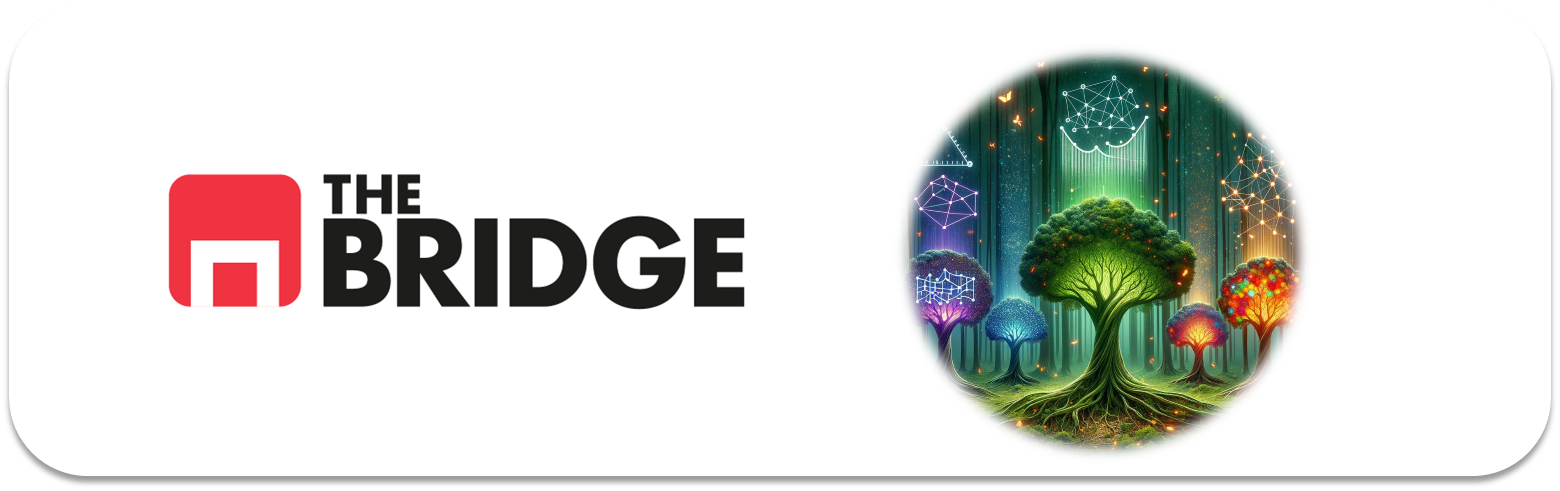

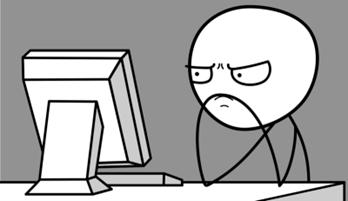

Para ejercitarte y afianzar lo aprendido sobre **Clasificacion con Árboles de decisión**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

df = pd.read_csv('./data/temps.csv')
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41


### Ejercicio 1

Genera un conjunto de datos de lunas usando 

```python
make_moons(n_samples=10000, noise=0.4)
```

La función make_moons se encuentra en el módulo `datasets` de `sklearn`. Juega con ella para ver qué tipo de datos genera, y  crea un X_moons y un y_moons. Visualiza las moons con un scatter plot de las dos features de X_moons. (ojo X_moons es un array de numpy de dos dimesiones para acceder a la primera X_moons[:,0] y para la segunda...)

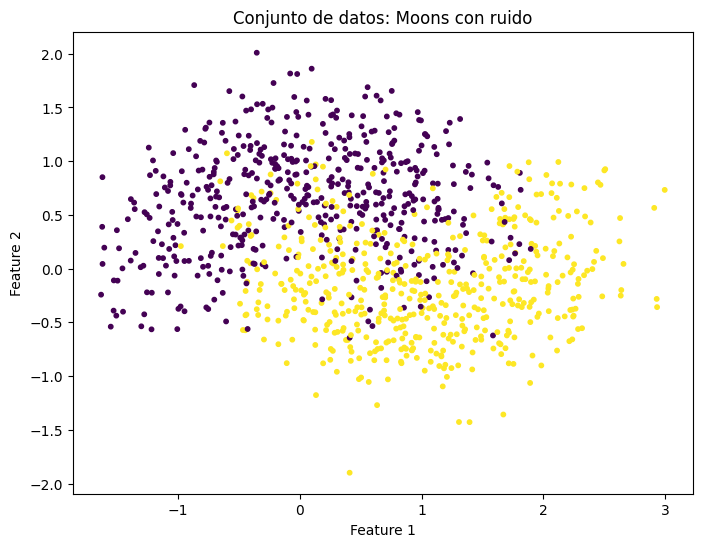

In [2]:
from sklearn.datasets import make_moons

X_moons, Y_moons= make_moons(n_samples=1000, noise=0.4)

plt.figure(figsize=(8, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=Y_moons, cmap="viridis", s=10)
plt.title("Conjunto de datos: Moons con ruido")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()




<Axes: >

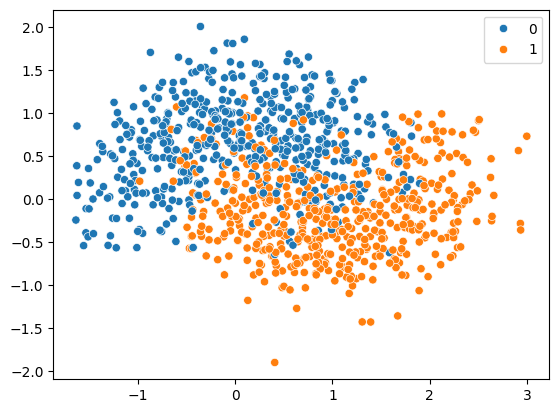

In [4]:
import seaborn as sns
sns.scatterplot(x = X_moons[:,0], y = X_moons[:,1], hue = Y_moons)

### Ejercicio 2

El objetivo de los modelos que vamos a ir construyendo es aprender a clasificar correctamente en cada "luna" (moon) a un punto dadas sus coordenadas. Para ello crea un par de juegos X,y para train y test al 20% de test a partir de los puntos generados en el ejercicio anterior.

In [5]:
from sklearn.model_selection import train_test_split

# Suponiendo que ya tienes X_moons y y_moons generados antes
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, 
    Y_moons, 
    test_size=0.20,      # 20% para test
    random_state=42,     # para reproducibilidad
    shuffle=True
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)


Tamaño de X_train: (800, 2)
Tamaño de X_test: (200, 2)
Tamaño de y_train: (800,)
Tamaño de y_test: (200,)


### Ejercicio 3

Instancia un árbol de decisión de `sklearn` sin añadir hiperparámetros.

In [6]:
from sklearn.tree import DecisionTreeClassifier

arbol = DecisionTreeClassifier()

### Ejercicio 4

Entrena el árbol y evalúalo contra test, usa para ello el classification_report de `sklearn`

In [8]:
from sklearn.metrics import classification_report

arbol.fit(X_train, y_train)

#Predecir sobre test
y_pred = arbol.predict(X_test)

#Evaluar con classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.85      0.85       113
           1       0.80      0.79      0.80        87

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



### Ejercicio 5

Instancia un nuevo árbol con los hiperparámetros (argumentos del constructor), `max_depth` a 5 y `max_leaf_nodes` a 15. Busca en la documentación de `sklearn` el significado de ambos hiperparámetros.

In [9]:
from sklearn.tree import DecisionTreeClassifier

arbol_limitado = DecisionTreeClassifier(
    max_depth=5,
    max_leaf_nodes=15
)


### Ejercicio 6

Entrénalo, evaluálo contra test y muestra el resultado a través del classification_report.

In [10]:
# Entrenar el modelo
arbol_limitado.fit(X_train, y_train)

# Predecir sobre test
y_pred_limitado = arbol_limitado.predict(X_test)

# Evaluar
print(classification_report(y_test, y_pred_limitado))


              precision    recall  f1-score   support

           0       0.85      0.88      0.86       113
           1       0.83      0.80      0.82        87

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



Comenta el resultado

*La mejor es sensible, debido a que el ajuste de hiperparámetros ha sido bastante bueno. En general los modelos basados en árboles necesitan un ajuste más fino que las regresiones (lineal, que apenas hay que hacer nada, y logística)*

### Ejercicio 7

Genera 1000 subconjuntos a partir del X_train, cada uno con 100 instancias seleccionadas aleatoriamente. Pista: Revisa la clase `ShuffleSplit` de `sklearn` para ayudarte con esto

In [11]:
from sklearn.model_selection import ShuffleSplit
import numpy as np

# Crear el generador ShuffleSplit
ss = ShuffleSplit(
    n_splits=1000,   # número de subconjuntos
    train_size=100, # tamaño de cada subconjunto
    test_size=None, # no necesitamos parte de test
    random_state=42
)

subconjuntos = []

# Generar los subconjuntos
for train_idx, _ in ss.split(X_train):
    subconjuntos.append(X_train[train_idx])

# subconjuntos es una lista de 1000 arrays, cada uno de tamaño (100, 2)
print(len(subconjuntos), subconjuntos[0].shape)

1000 (100, 2)


### Ejercicio 8

Entrena un árbol de decisión por cada subconjunto anterior (ve acumulándolos en una lista, llámala "bosque" o "forest"). Emplea como hiperparámetros los del ejercicio 5.

In [12]:
from sklearn.tree import DecisionTreeClassifier

forest = []

for subset in subconjuntos:
    arbol = DecisionTreeClassifier(
        max_depth=5,
        max_leaf_nodes=15
    )
    arbol.fit(subset, y_train[:subset.shape[0]])  # y correspondiente
    forest.append(arbol)

print("Número de árboles entrenados:", len(forest))

Número de árboles entrenados: 1000


### Ejercicio 9

Evalua cada árbol del bosque contra X_test original en la métrica de `accuracy` y muestra la media de todas las medidas. Emplea para ello `accuracy_score` de `sklearn`. Comenta el resultado.

In [13]:
from sklearn.metrics import accuracy_score
import numpy as np

accuracies = []

for arbol in forest:
    y_pred = arbol.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

media_accuracy = np.mean(accuracies)

print("Accuracy medio del bosque:", media_accuracy)


Accuracy medio del bosque: 0.49811500000000003


*Como era un poco de esperar un árbol entrenado con menor cantidad de datos no está a la altura de otro entrenado sobre el mismo dataset pero con mayor cantidad de información (81% vs 86%). Es lo que se denomina weak_learner*

### Ejercicio 10

Vamos a hacer un consejo de árboles... Es decir ahora vuelve a predecir las instancias de X_test para cada árbol pero guarda las predicciones en una lista. Es decir crea una lista con los 1000 conjuntos de predicciones (uno por cada árbol)

In [14]:
predicciones_forest = []

for arbol in forest:
    y_pred = arbol.predict(X_test)
    predicciones_forest.append(y_pred)

print(len(predicciones_forest), predicciones_forest[0].shape)


1000 (200,)


### Ejercicio 11

Ahora vamos a construir la predicción final del consejo de árboles mediante un mecanismo de "hard-voting" es decir para cada predicción escoge la clase más votada. Puedes hacerlo recorriendo cada lista de predicciones y contando cual clase tiene más votos y apuntándolo o usando `mode` (la moda) de `scipy`

In [ ]:
# Ejemplo de votación para la primera instancia de X_test
Y_pred_consejo = []
votos_0 = 0
votos_1 = 0
for i in range(n_trees):
    if predicciones_list[i][0] == 0:
        votos_0 += 1
    else:
        votos_1 += 1

if votos_0 > votos_1:
    Y_pred_consejo.append(0)
else:
    Y_pred_consejo.append(1)

In [15]:
import numpy as np

n_trees = len(predicciones_forest)
n_test = len(X_test)

Y_pred_consejo = []

for j in range(n_test):  # para cada instancia de test
    votos_0 = 0
    votos_1 = 0
    
    for i in range(n_trees):  # para cada árbol
        if predicciones_forest[i][j] == 0:
            votos_0 += 1
        else:
            votos_1 += 1
    
    # decisión final por mayoría
    if votos_0 > votos_1:
        Y_pred_consejo.append(0)
    else:
        Y_pred_consejo.append(1)

Y_pred_consejo = np.array(Y_pred_consejo)



### Ejercicio 12

Evalua las predicciones del consejo contra y_test y comenta el resultado. Utiliza `accuracy_score`

In [16]:
from sklearn.metrics import accuracy_score

accuracy_consejo = accuracy_score(y_test, Y_pred_consejo)
print("Accuracy del consejo de árboles:", accuracy_consejo)

Accuracy del consejo de árboles: 0.49
